# High-order PVD-Net —— Setting B (Wang–He–Wylie–Huang, 2:−1)

$$\varepsilon^2\phi''=-(2c_1-c_2),\qquad c_1'+2c_1\phi'=-J_1,\qquad c_2'-c_2\phi'=-J_2$$

| | |
|---|---|
| 离子 | $n=2$, $\alpha_1=2$, $\alpha_2=-1$ —— Ca²⁺ : Cl⁻ |
| 通道 | $h\equiv1$,  永久电荷 $Q\equiv0$ |
| 电中性 | 外区域 $2c_1=c_2$;  电流 $I=2J_1-J_2$ |
| 边界条件 | $V=1$, $L_1=1.0$, $L_2=1.5$, $R_1=2.5$, $R_2=1.0$ |
| 摄动参数 | $\varepsilon=10^{-2}$ |
| 训练步数 | $3\times10^5$ (分段: $5\times10^4+5\times10^4+2\times10^5$) |

非对称价数使外解非退化 ($c_{10}\neq c_{20}$), 内系统的首次积分结构改变,
匹配过程需解三次方程。参考解由 `scipy.integrate.solve_bvp` 求解完整 PNP 系统给出。


## 1. 导入库和设置


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.integrate import solve_bvp as scipy_bvp, trapezoid

# 自动选择计算设备
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")

# Matplotlib配置
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

# 边界层拉伸坐标最大值
XI_MAX = 15.0

# 离子价态
Z1, Z2 = 2, -1

使用设备: cuda


## 2. 边界条件与辅助函数


In [2]:
def create_boundary_conditions(V, L1, L2, R1, R2):
    return {
        'V': V,      # 施加电压
        'L1': L1,    # 左边界离子1 (价态+2) 浓度
        'L2': L2,    # 左边界离子2 (价态-1) 浓度
        'R1': R1,    # 右边界离子1浓度
        'R2': R2     # 右边界离子2浓度
    }


def get_c_L(bc):

    return (bc['L1'] * bc['L2']**2 / 4.0) ** (1.0/3.0)


def get_c_R(bc):
    """c_R = (R1 * R2^2 / 4)^{1/3}"""
    return (bc['R1'] * bc['R2']**2 / 4.0) ** (1.0/3.0)


def is_electroneutral(bc):
    """检查是否满足 2:-1 电中性条件: 2L1 = L2, 2R1 = R2"""
    return (abs(2*bc['L1'] - bc['L2']) < 1e-10 and
            abs(2*bc['R1'] - bc['R2']) < 1e-10)


def bc_to_string(bc):
    """边界条件的字符串表示"""
    status = "电中性(2:-1)" if is_electroneutral(bc) else "非电中性"
    return (f"BoundaryConditions(V={bc['V']}, "
            f"Left=[{bc['L1']}, {bc['L2']}], "
            f"Right=[{bc['R1']}, {bc['R2']}]) [{status}]")


def make_mlp(in_dim, out_dim, hidden=64, layers=4):
    net = [nn.Linear(in_dim, hidden), nn.SiLU()]
    for _ in range(layers - 1):
        net.append(nn.Linear(hidden, hidden))
        net.append(nn.SiLU())
    net.append(nn.Linear(hidden, out_dim))
    return nn.Sequential(*net)


def grad(y, x):
    """自动微分求梯度 dy/dx"""
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]


def safe_log(x, eps=1e-15):
    """安全对数运算"""
    return np.log(np.maximum(np.abs(x), eps))


def safe_div(a, b, eps=1e-12):
    """安全除法"""
    if abs(b) > eps:
        return a / b
    else:
        return 0.0


def softplus_pos(x):
    """确保正值的激活函数"""
    return nn.functional.softplus(x) + 0.01

## 3. 解析参考解 (2:-1 匹配渐近展开)


In [3]:
class AnalyticalReference:
    """解析零阶 + 一阶修正 + 精确解 (2:-1 价态)"""

    def __init__(self, eps, V, L1, L2, R1, R2):
        self.eps = eps
        self.V, self.L1, self.L2, self.R1, self.R2 = V, L1, L2, R1, R2

        # ---- 2:-1 电中性浓度与电位 ----
        # c_L = (L1 * L2^2 / 4)^{1/3}
        self.c_L = (L1 * L2**2 / 4.0) ** (1.0/3.0)
        self.c_R = (R1 * R2**2 / 4.0) ** (1.0/3.0)
        # phi_L = V - ln(L2/(2L1)) / 3
        self.phi_L = V - np.log(L2 / (2.0*L1)) / 3.0
        # phi_R = ln(2R1/R2) / 3
        self.phi_R = np.log(2.0*R1 / R2) / 3.0

        # ---- 零阶通量 (2:-1) ----
        # T0 = 3(c_L - c_R),  3c0' + T0 = 0
        self.T0 = 3.0 * (self.c_L - self.c_R)
        # I0 = 2 * T0 * (phi_R - phi_L) / ln(c_R/c_L)
        if abs(self.T0) > 1e-12:
            self.I0 = 2.0 * self.T0 * (self.phi_R - self.phi_L) / np.log(self.c_R / self.c_L)
        else:
            # T0→0 极限: I0 = 6 c_L (phi_R - phi_L)
            self.I0 = 6.0 * self.c_L * (self.phi_R - self.phi_L)

        # J10 = (I0 + T0)/3,  J20 = (2T0 - I0)/3
        self.J10 = (self.I0 + self.T0) / 3.0
        self.J20 = (2.0*self.T0 - self.I0) / 3.0

        # ---- 零阶外解在端点的导数 ----
        # phi0' = -I0/(6c0),  c0' = -T0/3
        self.dphi0_0 = -self.I0 / (6.0 * self.c_L)    # at x=0
        self.dc0_0   = -self.T0 / 3.0                   # at x=0
        self.dphi0_1 = -self.I0 / (6.0 * self.c_R)    # at x=1
        self.dc0_1   = -self.T0 / 3.0                   # at x=1

        # 惰性计算
        self._inner_L0 = None
        self._inner_R0 = None
        self._first_order = None
        self._exact = None

    # ================================================================
    #  零阶内部边界层 (数值求解, 2:-1 无解析闭式)
    # ================================================================
    def _solve_inner_L0(self, xi_max=30.0, n_pts=1000):

        if self._inner_L0 is not None:
            return self._inner_L0
        c_L = self.c_L
        delta_L = self.V - self.phi_L

        def ode(xi, y):
            psi, dpsi = y
            ddpsi = -2.0*c_L*(np.exp(-2.0*psi) - np.exp(psi))
            return np.vstack([dpsi, ddpsi])

        def bc(ya, yb):
            return np.array([ya[0] - delta_L, yb[0]])

        xi_mesh = np.linspace(0, xi_max, n_pts)
        y_init = np.zeros((2, n_pts))
        y_init[0] = delta_L * np.exp(-np.sqrt(3.0*c_L) * xi_mesh)  # 初始猜测
        y_init[1] = -np.sqrt(3.0*c_L) * y_init[0]

        sol = scipy_bvp(ode, bc, xi_mesh, y_init, tol=1e-10, max_nodes=10000)
        assert sol.success, f"左零阶内部 BVP 失败: {sol.message}"
        self._inner_L0 = sol
        return sol

    def _solve_inner_R0(self, xi_max=30.0, n_pts=1000):

        if self._inner_R0 is not None:
            return self._inner_R0
        c_R = self.c_R
        delta_R = -self.phi_R  # Ψ0(0) = 0, phi_R = outer value

        def ode(eta, y):
            psi, dpsi = y
            ddpsi = -2.0*c_R*(np.exp(-2.0*psi) - np.exp(psi))
            return np.vstack([dpsi, ddpsi])

        def bc(ya, yb):
            return np.array([ya[0], yb[0] - delta_R])

        eta_mesh = np.linspace(-xi_max, 0, n_pts)
        y_init = np.zeros((2, n_pts))
        y_init[0] = delta_R * np.exp(np.sqrt(3.0*c_R) * eta_mesh)
        y_init[1] = np.sqrt(3.0*c_R) * y_init[0]

        sol = scipy_bvp(ode, bc, eta_mesh, y_init, tol=1e-10, max_nodes=10000)
        assert sol.success, f"右零阶内部 BVP 失败: {sol.message}"
        self._inner_R0 = sol
        return sol

    def _eval_inner_L0(self, xi):
        """计算左零阶内部解: Φ0, C10, C20"""
        sol = self._solve_inner_L0()
        xi = np.clip(xi, 0, 30.0)
        y = sol.sol(xi)
        psi = y[0]
        Phi0  = self.phi_L + psi
        C10   = self.c_L * np.exp(-2.0 * psi)
        C20   = 2.0 * self.c_L * np.exp(psi)
        dPhi0 = y[1]   # Φ0' = ψ'
        return Phi0, dPhi0, C10, C20

    def _eval_inner_R0(self, eta):
        """计算右零阶内部解: Ψ0, D10, D20"""
        sol = self._solve_inner_R0()
        eta = np.clip(eta, -30.0, 0)
        y = sol.sol(eta)
        psi = y[0]
        Psi0 = self.phi_R + psi
        D10  = self.c_R * np.exp(-2.0 * psi)
        D20  = 2.0 * self.c_R * np.exp(psi)
        dPsi0 = y[1]
        return Psi0, dPsi0, D10, D20

    # ---- 零阶复合解 ----
    def zeroth_order(self, x):
        """零阶复合解 (外部 + 左右边界层修正)"""
        x = np.asarray(x)
        # 外部解
        c0 = self.c_L - self.T0 * x / 3.0
        M = 3.0 * self.c_L
        if abs(self.T0) > 1e-12:
            phi0 = (self.phi_L - (self.I0/(2.0*self.T0))*np.log(M)
                    + (self.I0/(2.0*self.T0))*np.log(np.abs(M - self.T0*x)))
        else:
            phi0 = self.phi_L + self.I0 * x / (6.0*self.c_L)

        # 左边界层修正
        xi = x / self.eps
        xi_safe = np.minimum(xi, 30.0)
        Phi0_L, _, C10_L, C20_L = self._eval_inner_L0(xi_safe)
        # 远场值 (= 外解 x=0 的值)
        phi_corr_L = Phi0_L - self.phi_L
        c1_corr_L  = C10_L - self.c_L
        c2_corr_L  = C20_L - 2.0*self.c_L

        # 右边界层修正
        eta = (x - 1.0) / self.eps
        eta_safe = np.maximum(eta, -30.0)
        Psi0_R, _, D10_R, D20_R = self._eval_inner_R0(eta_safe)
        phi_corr_R = Psi0_R - self.phi_R
        c1_corr_R  = D10_R - self.c_R
        c2_corr_R  = D20_R - 2.0*self.c_R

        phi = phi0 + phi_corr_L + phi_corr_R
        c1  = c0 + c1_corr_L + c1_corr_R
        c2  = 2.0*c0 + c2_corr_L + c2_corr_R
        return phi, np.maximum(c1, 1e-10), np.maximum(c2, 1e-10)

    # ---- 一阶修正 (BVP 求解) ----
    def compute_first_order(self):
        if self._first_order is not None:
            return self._first_order

        J10, J20 = self.J10, self.J20
        xi_bvp_max = 30.0

        # 预计算零阶内部解 (用于一阶 ODE 的系数)
        self._solve_inner_L0(xi_bvp_max)
        self._solve_inner_R0(xi_bvp_max)

        def ode_L(xi, y):
            _, dPhi0, C10, C20 = self._eval_inner_L0(xi)
            return np.array([
                y[1],
                -(2.0*y[2] - y[3]),
                -2.0*y[2]*dPhi0 - 2.0*C10*y[1] - J10,
                y[3]*dPhi0 + C20*y[1] - J20
            ])

        def bc_L(ya, yb):
            # Φ1(0)=0, C11(0)=0, C21(0)=0, 远场电中性 2C11-C21=0
            return np.array([ya[0], ya[2], ya[3], 2.0*yb[2] - yb[3]])

        xm = np.linspace(0, xi_bvp_max, 500)
        yi = np.zeros((4, 500))
        yi[1,:] = self.dphi0_0
        yi[2,:] = self.dc0_0 * xm
        yi[3,:] = 2.0 * self.dc0_0 * xm   # c2 = 2c1 → dc2/dx = 2·dc1/dx
        sol_L = scipy_bvp(ode_L, bc_L, xm, yi, tol=1e-10, max_nodes=10000)
        assert sol_L.success, f"左一阶 BVP 失败: {sol_L.message}"

        yL = sol_L.sol(xi_bvp_max)
        phi1_0 = yL[0] - xi_bvp_max * self.dphi0_0
        c1_0   = yL[2] - xi_bvp_max * self.dc0_0     # c1 一阶修正

        # ---- 右一阶 BVP ----
        def ode_R(eta, y):
            _, dPsi0, D10, D20 = self._eval_inner_R0(eta)
            return np.array([
                y[1],
                -(2.0*y[2] - y[3]),
                -2.0*y[2]*dPsi0 - 2.0*D10*y[1] - J10,
                y[3]*dPsi0 + D20*y[1] - J20
            ])

        def bc_R(ya, yb):
            return np.array([yb[0], yb[2], yb[3], 2.0*ya[2] - ya[3]])

        em = np.linspace(-xi_bvp_max, 0, 500)
        yi_R = np.zeros((4, 500))
        yi_R[1,:] = self.dphi0_1
        yi_R[2,:] = self.dc0_1 * em
        yi_R[3,:] = 2.0 * self.dc0_1 * em
        sol_R = scipy_bvp(ode_R, bc_R, em, yi_R, tol=1e-10, max_nodes=10000)
        assert sol_R.success, f"右一阶 BVP 失败: {sol_R.message}"

        yR = sol_R.sol(-xi_bvp_max)
        phi1_1 = yR[0] - (-xi_bvp_max) * self.dphi0_1
        c1_1   = yR[2] - (-xi_bvp_max) * self.dc0_1

        # ---- 确定 T1, I1 ----
        # 3c1' + T1 = 0 → c1(x) = c1_0 - T1·x/3
        T1 = 3.0 * (c1_0 - c1_1)
        xq  = np.linspace(0, 1, 10000)
        c0q = self.c_L - self.T0 * xq / 3.0
        c1q = c1_0 - T1 * xq / 3.0
        # phi1' = -I1/(6c0) + I0·c1/(6c0^2)
        # phi1(1)-phi1(0) = -I1·A + I0·B
        A = trapezoid(1.0/(6.0*c0q), xq)
        B = trapezoid(c1q/(6.0*c0q**2), xq)
        I1 = (self.I0 * B - (phi1_1 - phi1_0)) / A

        # J11 = (I1+T1)/3, J21 = (2T1-I1)/3
        self._first_order = {
            'phi1_0': phi1_0, 'phi1_1': phi1_1,
            'c1_0': c1_0, 'c1_1': c1_1,
            'T1': T1, 'I1': I1,
            'J11': (I1 + T1) / 3.0,
            'J21': (2.0*T1 - I1) / 3.0,
            'sol_L': sol_L, 'sol_R': sol_R,
            'xi_bvp_max': xi_bvp_max,
        }
        return self._first_order

    # ---- 精确 BVP 解 ----
    def compute_exact(self):
        if self._exact is not None:
            return self._exact

        eps = self.eps

        def pnp_ode(x, y):
            phi, dphi, c1, c2, J1v, J2v = y
            return np.vstack([
                dphi,
                -(2.0*c1 - c2) / eps**2,   # 2:-1 Poisson
                -2.0*c1*dphi - J1v,          # z1=2 NP
                c2*dphi - J2v,               # z2=-1 NP
                np.zeros_like(x),
                np.zeros_like(x)
            ])

        def pnp_bc(ya, yb):
            return np.array([
                ya[0] - self.V, yb[0],
                ya[2] - self.L1, yb[2] - self.R1,
                ya[3] - self.L2, yb[3] - self.R2
            ])

        x_init = np.linspace(0, 1, 5000)
        phi0, c1_0, c2_0 = self.zeroth_order(x_init)
        y0 = np.zeros((6, len(x_init)))
        y0[0] = phi0
        y0[1] = np.gradient(phi0, x_init)
        y0[2] = c1_0
        y0[3] = c2_0
        y0[4] = self.J10
        y0[5] = self.J20

        sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
        assert sol.success, f"精确解 BVP 失败: {sol.message}"
        self._exact = sol
        return sol

    def exact_solution(self, x):
        sol = self.compute_exact()
        y = sol.sol(x)
        return y[0], y[2], y[3], y[4,0], y[5,0]

## 4. 一阶 PVD-Net (联合训练) 模型


In [4]:
def create_pvdnet(eps, hidden=100, layers=5, device=DEVICE):

    model = {
        'eps': eps,
        'device': device,
        'outer': {},
        'inner': {},
        'flux_params': []
    }

    # 外部解网络 (零阶 + 一阶)
    model['outer']['0'] = make_mlp(1, 2, hidden, layers).to(device)
    model['outer']['1'] = make_mlp(1, 2, hidden, layers).to(device)

    # 内部解网络
    for key in ['L0', 'Lc', 'L1', 'R0', 'Rc', 'R1']:
        model['inner'][key] = make_mlp(1, 3, hidden, layers).to(device)

    # 通量参数 (可学习)
    model['flux_params'].append(nn.Parameter(torch.tensor([0.1], device=device)))   # J1_0
    model['flux_params'].append(nn.Parameter(torch.tensor([0.1], device=device)))   # J2_0
    model['flux_params'].append(nn.Parameter(torch.tensor([0.0], device=device)))   # J1_1
    model['flux_params'].append(nn.Parameter(torch.tensor([0.0], device=device)))   # J2_1

    # 初始化权重
    for key in model['outer']:
        for m in model['outer'][key].modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
    for key in model['inner']:
        for m in model['inner'][key].modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    return model


def get_all_parameters(model):
    """获取所有可训练参数"""
    params = []
    for net in model['outer'].values():
        params.extend(net.parameters())
    for net in model['inner'].values():
        params.extend(net.parameters())
    params.extend(model['flux_params'])
    return params


def get_flux(model):
    """获取通量值"""
    return (model['flux_params'][0].item(), model['flux_params'][1].item(),
            model['flux_params'][2].item(), model['flux_params'][3].item())


def _eval_inner(net, z, clamp_lo, clamp_hi, pos_mask=(False, False, False)):
    """内部网络前向传播 (带 clamp 和正值约束)"""
    zc = z.clamp(clamp_lo, clamp_hi)
    out = net(zc)
    cols = []
    for i in range(3):
        c = out[:, i:i+1]
        cols.append(softplus_pos(c) if pos_mask[i] else c)
    return cols


def get_outer_solution(model, x, order):

    out = model['outer'][str(order)](x)
    phi, c = out[:, 0:1], out[:, 1:2]
    if order == 0:
        c = softplus_pos(c)
    return phi, c, 2.0 * c    # ★ 2:-1 核心改动: c2 = 2*c1


def get_inner_solution(model, z, side, order='0'):

    key = side + order
    net = model['inner'][key]
    lo, hi = (0, XI_MAX) if side == 'L' else (-XI_MAX, 0)
    pos = (False, True, True) if order == '0' else (False, False, False)
    return _eval_inner(net, z, lo, hi, pos)


def get_full_inner_1(model, z, side):
    """获取完整一阶内部解: z·c(z) + d(z)"""
    fc = get_inner_solution(model, z, side, 'c')
    fd = get_inner_solution(model, z, side, '1')
    return [z * c + d for c, d in zip(fc, fd)]


def _bl_correction(model, z, z_far, side, order):
    """计算边界层修正项 (内解 - 远场匹配值)"""
    if order == 0:
        vals = get_inner_solution(model, z, side, '0')
        vals_far = get_inner_solution(model, z_far, side, '0')
        return [v - vf for v, vf in zip(vals, vals_far)]
    else:
        fc = get_inner_solution(model, z, side, 'c')
        fc_far = get_inner_solution(model, z_far, side, 'c')
        fd = get_inner_solution(model, z, side, '1')
        fd_far = get_inner_solution(model, z_far, side, '1')
        return [z * (c - cf) + (d - df)
                for c, cf, d, df in zip(fc, fc_far, fd, fd_far)]


def forward_pvdnet(model, x):

    eps = model['eps']
    dev = model['device']
    xi, eta = x / eps, (x - 1.0) / eps
    xi_far = torch.tensor([[XI_MAX]], device=dev)
    eta_far = torch.tensor([[-XI_MAX]], device=dev)

    # 外部解
    o0 = get_outer_solution(model, x, 0)
    o1 = get_outer_solution(model, x, 1)

    # 边界层修正
    dL0 = _bl_correction(model, xi, xi_far, 'L', 0)
    dL1 = _bl_correction(model, xi, xi_far, 'L', 1)
    dR0 = _bl_correction(model, eta, eta_far, 'R', 0)
    dR1 = _bl_correction(model, eta, eta_far, 'R', 1)

    # 组装复合解
    result = []
    for i in range(3):
        result.append(
            (o0[i] + eps * o1[i])
            + dL0[i] + eps * dL1[i]
            + dR0[i] + eps * dR1[i]
        )
    return result

## 5. 损失函数


In [5]:
def sample_points(n, device):
    """在 [0,1] 上采样配点"""
    return torch.rand(n, 1, device=device).requires_grad_(True)


def outer_pde_loss(model, x, order):

    J10, J20 = model['flux_params'][0], model['flux_params'][1]
    J11, J21 = model['flux_params'][2], model['flux_params'][3]

    phi0, c0, _ = get_outer_solution(model, x, 0)
    dphi0, dc0 = grad(phi0, x), grad(c0, x)

    if order == 0:
        T = J10 + J20            # T₀ = J₁₀ + J₂₀
        I = 2.0*J10 - J20       # I₀ = 2J₁₀ - J₂₀  ★
        r1 = 3.0 * dc0 + T      # 3c₀' + T₀ = 0      ★
        r2 = 6.0 * c0 * dphi0 + I  # 6c₀φ₀' + I₀ = 0  ★
    else:
        phi1, c1, _ = get_outer_solution(model, x, 1)
        dphi1, dc1 = grad(phi1, x), grad(c1, x)
        T = J11 + J21
        I = 2.0*J11 - J21       # ★
        r1 = 3.0 * dc1 + T      # ★
        r2 = 6.0 * (c1 * dphi0 + c0 * dphi1) + I  # ★

    return torch.mean(r1**2 + r2**2)


def inner_pde_loss_0(model, z, side):

    P, C1, C2 = get_inner_solution(model, z, side, '0')
    dP, dC1, dC2 = grad(P, z), grad(C1, z), grad(C2, z)
    ddP = grad(dP, z)
    return torch.mean(
        (ddP + 2.0*C1 - C2)**2 +    # ★ Poisson: 2C1 - C2
        (dC1 + 2.0*C1*dP)**2 +      # ★ NP1: z1=2
        (dC2 - C2*dP)**2             #   NP2: z2=-1 (不变)
    )


def inner_pde_loss_1(model, z, side):

    J10 = model['flux_params'][0]
    J20 = model['flux_params'][1]

    P0, C10, C20 = get_inner_solution(model, z, side, '0')
    dP0 = grad(P0, z)
    P1, C11, C21 = get_full_inner_1(model, z, side)
    dP1, dC11, dC21 = grad(P1, z), grad(C11, z), grad(C21, z)
    ddP1 = grad(dP1, z)

    r1 = ddP1 + 2.0*C11 - C21                       # ★ Poisson
    r2 = dC11 + 2.0*C11*dP0 + 2.0*C10*dP1 + J10    # ★ NP1 (z1=2)
    r3 = dC21 - C21*dP0 - C20*dP1 + J20              #   NP2 (不变)
    return torch.mean(r1**2 + r2**2 + r3**2)


def boundary_loss(model, V, L1, L2, R1, R2):

    z0 = torch.zeros(1, 1, device=model['device'])

    # 零阶边界
    PL, C1L, C2L = get_inner_solution(model, z0, 'L', '0')
    PR, C1R, C2R = get_inner_solution(model, z0, 'R', '0')
    loss_0 = ((PL-V)**2 + (C1L-L1)**2 + (C2L-L2)**2
              + PR**2 + (C1R-R1)**2 + (C2R-R2)**2)

    # 一阶边界: 衰减项在 z=0 处为零
    PL1, CL1a, CL1b = get_inner_solution(model, z0, 'L', '1')
    PR1, CR1a, CR1b = get_inner_solution(model, z0, 'R', '1')
    loss_1 = PL1**2 + CL1a**2 + CL1b**2 + PR1**2 + CR1a**2 + CR1b**2

    return (loss_0 + loss_1).mean()


def matching_loss(model):

    dev = model['device']
    xi_f  = torch.tensor([[XI_MAX]], device=dev)
    eta_f = torch.tensor([[-XI_MAX]], device=dev)
    x0 = torch.zeros(1, 1, device=dev, requires_grad=True)
    x1 = torch.ones(1, 1, device=dev, requires_grad=True)

    loss = torch.tensor(0.0, device=dev)

    # 外解在端点的值和导数
    p0_0, c1_0_0, c2_0_0 = get_outer_solution(model, x0, 0)   # c2 = 2*c1 ★
    p0_1, c1_0_1, c2_0_1 = get_outer_solution(model, x1, 0)
    dp0_0  = grad(p0_0, x0)
    dc1_0_0 = grad(c1_0_0, x0)
    dc2_0_0 = grad(c2_0_0, x0)   # = 2 * dc1_0_0 ★
    dp0_1  = grad(p0_1, x1)
    dc1_0_1 = grad(c1_0_1, x1)
    dc2_0_1 = grad(c2_0_1, x1)

    p1_0, c1_1_0, c2_1_0 = get_outer_solution(model, x0, 1)   # c2 = 2*c1 ★
    p1_1, c1_1_1, c2_1_1 = get_outer_solution(model, x1, 1)

    for (side, zf,
         p_val, c1_val, c2_val,
         dp_val, dc1_val, dc2_val,
         p1_val, c1_1_val, c2_1_val) in [
        ('L', xi_f,
         p0_0, c1_0_0, c2_0_0,
         dp0_0, dc1_0_0, dc2_0_0,
         p1_0, c1_1_0, c2_1_0),
        ('R', eta_f,
         p0_1, c1_0_1, c2_0_1,
         dp0_1, dc1_0_1, dc2_0_1,
         p1_1, c1_1_1, c2_1_1),
    ]:
        i0  = get_inner_solution(model, zf, side, '0')
        ic  = get_inner_solution(model, zf, side, 'c')
        i1d = get_inner_solution(model, zf, side, '1')

        # 零阶匹配: 内解远场 ↔ 外解端点
        loss = loss + (i0[0] - p_val)**2
        loss = loss + (i0[1] - c1_val)**2    # C1 ↔ c1
        loss = loss + (i0[2] - c2_val)**2    # C2 ↔ c2=2c1 ★

        # 一阶线性系数匹配: 内解增长率 ↔ 外解导数
        loss = loss + (ic[0] - dp_val)**2
        loss = loss + (ic[1] - dc1_val)**2   # dC1/dξ → dc1/dx
        loss = loss + (ic[2] - dc2_val)**2   # dC2/dξ → dc2/dx = 2·dc1/dx ★

        # 一阶衰减项匹配: 远场衰减值 ↔ 外解一阶端点
        loss = loss + (i1d[0] - p1_val)**2
        loss = loss + (i1d[1] - c1_1_val)**2
        loss = loss + (i1d[2] - c2_1_val)**2  # ★ c2_1 = 2*c1_1

    return loss.mean()


def compute_loss(model, V, L1, L2, R1, R2):

    dev = model['device']
    x_o = sample_points(200, dev)
    xi  = (torch.rand(150, 1, device=dev) * XI_MAX).requires_grad_(True)
    eta = (-torch.rand(150, 1, device=dev) * XI_MAX).requires_grad_(True)

    losses = {
        'outer_0': outer_pde_loss(model, x_o, 0),
        'outer_1': outer_pde_loss(model, x_o, 1),
        'inner_0': inner_pde_loss_0(model, xi, 'L') + inner_pde_loss_0(model, eta, 'R'),
        'inner_1': inner_pde_loss_1(model, xi, 'L') + inner_pde_loss_1(model, eta, 'R'),
        'match':   matching_loss(model),
        'bc':      boundary_loss(model, V, L1, L2, R1, R2),
    }

    total = (losses['outer_0'] + losses['outer_1']
             + losses['inner_0'] + losses['inner_1']
             + 10 * losses['match'] + 50 * losses['bc'])

    return total, {k: v.item() for k, v in losses.items()}

## 6. 训练函数


In [6]:
def train(model, V, L1, L2, R1, R2, epochs=80000, log_interval=1000):
    """
    训练一阶 PVD-Net 模型 (同时训练策略)

    返回: 训练历史
    """
    params = get_all_parameters(model)
    optimizer = torch.optim.Adam(params, lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs, eta_min=1e-6
    )

    history = {'loss': [], 'J1': [], 'J2': []}
    best_loss = float('inf')                             
    best_state = [p.data.clone() for p in params]          

    for ep in range(epochs):
        optimizer.zero_grad()
        loss, details = compute_loss(model, V, L1, L2, R1, R2)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(params, 1.0)

        optimizer.step()
        scheduler.step()

        if loss.item() < best_loss:                        
            best_loss = loss.item()                         
            best_state = [p.data.clone() for p in params]  

        J10, J20, J11, J21 = get_flux(model)
        history['loss'].append(loss.item())
        history['J1'].append(J10)
        history['J2'].append(J20)

        if (ep + 1) % log_interval == 0:
            print(f"Epoch {ep+1:6d}/{epochs} | Loss: {loss.item():.4e} | "
                  f"J10={J10:.4f}, J20={J20:.4f}, J11={J11:.4f}, J21={J21:.4f}")

    for p, b in zip(params, best_state):                   
        p.data.copy_(b)                                     
    
    print(f'训练完成! 最佳损失: {best_loss:.4e}')
    return history

## 7. 问题设置与单次训练


In [7]:
# 物理参数设置
eps = 1e-2    # Debye长度参数
V = 1.0       # 施加电压

# 边界浓度 (非电中性情形, 2:-1 价态)
L1 = 1.0      # 左边界 z1=+2 离子浓度
L2 = 1.5      # 左边界 z2=-1 离子浓度
R1 = 2.5      # 右边界 z1=+2 离子浓度
R2 = 1.0      # 右边界 z2=-1 离子浓度

print('  1st-order PVD-Net for 2:-1 PNP System (Simultaneous Training)')
print(f"  Valences: z1 = {Z1}, z2 = {Z2}")
print(f"  ε = {eps},  V = {V}")
print(f"  Left BC:  L1 = {L1}, L2 = {L2}")
print(f"  Right BC: R1 = {R1}, R2 = {R2}")

bc = create_boundary_conditions(V, L1, L2, R1, R2)
print(f"  {bc_to_string(bc)}")

hidden = 33
epochs = 300000

# 计算解析参考值
ref = AnalyticalReference(eps, V, L1, L2, R1, R2)
fo = ref.compute_first_order()

print(f"解析参考值 (2:-1):")
print(f"  c_L = {ref.c_L:.6f}, c_R = {ref.c_R:.6f}")
print(f"  phi_L = {ref.phi_L:.6f}, phi_R = {ref.phi_R:.6f}")
print(f"  T0 = {ref.T0:.6f}, I0 = {ref.I0:.6f}")
print(f"  J10 = {ref.J10:.6f}, J20 = {ref.J20:.6f}")
print(f"  J11 = {fo['J11']:.6f}, J21 = {fo['J21']:.6f}")

model = create_pvdnet(eps, hidden=hidden, layers=5, device=DEVICE)

param_count = sum(p.numel() for p in get_all_parameters(model))
print(f"\n模型参数量: {param_count:,}")

import time

start_time = time.time()
# 训练模型
history = train(model, V, L1, L2, R1, R2, epochs=epochs, log_interval=1000)
end_time = time.time() # 记录结束时间

print(f"程序运行时间：{end_time - start_time} 秒")

from scipy.integrate import solve_bvp as scipy_bvp, trapezoid

  1st-order PVD-Net for 2:-1 PNP System (Simultaneous Training)
  Valences: z1 = 2, z2 = -1
  ε = 0.01,  V = 1.0
  Left BC:  L1 = 1.0, L2 = 1.5
  Right BC: R1 = 2.5, R2 = 1.0
  BoundaryConditions(V=1.0, Left=[1.0, 1.5], Right=[2.5, 1.0]) [非电中性]
解析参考值 (2:-1):
  c_L = 0.825482, c_R = 0.854988
  phi_L = 1.095894, phi_R = 0.536479
  T0 = -0.088518, I0 = 2.819949
  J10 = 0.910477, J20 = -0.998995
  J11 = 0.310335, J21 = 0.387590

模型参数量: 37,184
Epoch   1000/300000 | Loss: 1.8809e-02 | J10=0.0553, J20=-0.0383, J11=-0.0005, J21=-0.0010
Epoch   2000/300000 | Loss: 8.2082e-03 | J10=0.1464, J20=-0.1481, J11=0.0455, J21=-0.0458
Epoch   3000/300000 | Loss: 5.6457e-03 | J10=0.2516, J20=-0.2706, J11=0.0822, J21=-0.0573
Epoch   4000/300000 | Loss: 6.0048e-03 | J10=0.3480, J20=-0.3735, J11=0.0839, J21=-0.0489
Epoch   5000/300000 | Loss: 3.9485e-03 | J10=0.4466, J20=-0.4906, J11=0.1091, J21=-0.0323
Epoch   6000/300000 | Loss: 2.6534e-03 | J10=0.5117, J20=-0.5703, J11=0.1180, J21=-0.0139
Epoch   7000/300

## 8. 精确参考解


In [8]:
def compute_exact_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    """
    用 scipy solve_bvp 求完整 2:-1 PNP 系统的精确数值解
    """
    ref = AnalyticalReference(eps, V, L1, L2, R1, R2)

    x_init = np.linspace(0, 1, n_init)
    phi0, c1_0, c2_0 = ref.zeroth_order(x_init)

    y0 = np.zeros((6, n_init))
    y0[0] = phi0
    y0[1] = np.gradient(phi0, x_init)
    y0[2] = np.maximum(c1_0, 1e-6)
    y0[3] = np.maximum(c2_0, 1e-6)
    y0[4] = ref.J10
    y0[5] = ref.J20

    def pnp_ode(x, y):
        phi, E, c1, c2, J1, J2 = y
        return np.vstack([
            E,
            -(2.0*c1 - c2) / eps**2,     # ★ 2:-1 Poisson
            -2.0*c1*E - J1,               # ★ z1=2 NP
            c2*E - J2,                     #   z2=-1 NP
            np.zeros_like(x),
            np.zeros_like(x)
        ])

    def pnp_bc(ya, yb):
        return np.array([ya[0]-V, yb[0], ya[2]-L1, yb[2]-R1, ya[3]-L2, yb[3]-R2])

    sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f'精确解求解失败: {sol.message}'
    return sol

## 9. 统一评估网格与误差指标


In [9]:
def create_evaluation_grid(eps, n_inner_per_side=2500, n_outer=200):
    """按论文方式创建分区评估网格"""
    bl_w = min(10 * eps, 0.05)  # 边界层宽度
    
    # 左边界层: [0, bl_w] 密集采点
    x_left_bl = np.linspace(0, bl_w, n_inner_per_side, endpoint=False)
    
    # 右边界层: [1-bl_w, 1] 密集采点
    x_right_bl = np.linspace(1 - bl_w, 1, n_inner_per_side, endpoint=True)
    
    # 交界点
    x_junction = np.array([bl_w, 1 - bl_w])
    
    # 外区域: (bl_w, 1-bl_w) 均匀采点
    x_outer = np.linspace(bl_w, 1 - bl_w, n_outer + 2)[1:-1]  # 去掉端点避免重复
    
    # 合并并排序
    x_all = np.sort(np.unique(np.concatenate([x_left_bl, x_right_bl, x_junction, x_outer])))
    
    # 记录各区域的索引掩码
    return {
        'x': x_all,
        'n': len(x_all),
        'bl_width': bl_w,
        'eps': eps,
        'mask_left_bl': x_all <= bl_w,
        'mask_right_bl': x_all >= 1 - bl_w,
        'mask_inner': (x_all <= bl_w) | (x_all >= 1 - bl_w),       # 所有边界层点
        'mask_outer': (x_all > bl_w) & (x_all < 1 - bl_w),          # 外区域
        'junction_left': np.argmin(np.abs(x_all - bl_w)),            # 左交界点索引
        'junction_right': np.argmin(np.abs(x_all - (1 - bl_w))),     # 右交界点索引
    }


def compute_unified_metrics(phi_a, c1_a, c2_a, J1_a, J2_a,
                            phi_e, c1_e, c2_e, J1_e, J2_e, grids):
    """
    按论文 Table 2 的五项指标评估:
    ① 全局相对 L²   ② 全局 L∞
    ③ 内区域相对 L²  ④ 内区域 L∞
    ⑤ 交界点误差
    """
    x = grids['x']
    mask_inner = grids['mask_inner']
    mask_left_bl = grids['mask_left_bl']
    mask_right_bl = grids['mask_right_bl']
    jL = grids['junction_left']
    jR = grids['junction_right']
    
    results = {}
    for name, ua, ue in [('phi', phi_a, phi_e), ('c1', c1_a, c1_e), ('c2', c2_a, c2_e)]:
        err = np.abs(ua - ue)
        
        # ① 全局相对 L²
        norm_e = np.sqrt(trapezoid(ue**2, x))
        norm_err = np.sqrt(trapezoid(err**2, x))
        global_rel_L2 = norm_err / max(norm_e, 1e-16)
        
        # ② 全局 L∞
        global_Linf = np.max(err)
        
        # ③ 内区域（边界层）相对 L²
        # 左右两段是不相连的区间，必须分别积分后相加。若直接对拼接后的节点
        # 数组调用 trapezoid，会在 w_BL 与 1-w_BL 之间多出一段宽度
        # (1-2*w_BL) 的伪梯形，分子分母同时被污染。
        def _int_sq(v, m):
            return trapezoid(v[m]**2, x[m]) if np.count_nonzero(m) > 1 else 0.0
        den_sq = _int_sq(ue, mask_left_bl) + _int_sq(ue, mask_right_bl)
        num_sq = _int_sq(err, mask_left_bl) + _int_sq(err, mask_right_bl)
        if den_sq > 0.0:
            inner_rel_L2 = np.sqrt(num_sq) / max(np.sqrt(den_sq), 1e-16)
        else:
            inner_rel_L2 = np.nan
        
        # ④ 内区域 L∞
        inner_Linf = np.max(err[mask_inner]) if np.any(mask_inner) else np.nan
        
        # ⑤ 交界点误差 (取左右交界点的最大误差)
        junction_err = max(err[jL], err[jR])
        
        results[name] = {
            'global_rel_L2': global_rel_L2,
            'global_Linf': global_Linf,
            'inner_rel_L2': inner_rel_L2,
            'inner_Linf': inner_Linf,
            'junction_err': junction_err,
        }
    
    # 通量和电流指标保持不变
    results['flux'] = {
        'J1_rel_err': abs(J1_a - J1_e) / max(abs(J1_e), 1e-16),
        'J2_rel_err': abs(J2_a - J2_e) / max(abs(J2_e), 1e-16),
    }
    I_a, I_e = 2.0*J1_a - J2_a, 2.0*J1_e - J2_e   # ★ 2:-1 价数
    results['current'] = {
        'I_rel_err': abs(I_a - I_e) / max(abs(I_e), 1e-16),
        'I_approx': I_a, 'I_exact': I_e,
    }
    return results


def print_unified_table(metrics, method_name, eps):
    print(f'  统一评估: {method_name}  (ε = {eps})')
    print(f'  参考解: 完整 PNP 系统 scipy BVP 精确数值解')
    print(f"  {'指标':<22s} | {'phi':>12s} | {'c1':>12s} | {'c2':>12s}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    for mk, ml in [('global_rel_L2', '① 全局相对 L²'),
                    ('global_Linf',   '② 全局 L∞'),
                    ('inner_rel_L2',  '③ 内区域相对 L²'),
                    ('inner_Linf',    '④ 内区域 L∞'),
                    ('junction_err',  '⑤ 交界点误差')]:
        vals = [metrics[v][mk] for v in ['phi', 'c1', 'c2']]
        print(f"  {ml:<22s} | {vals[0]:>12.4e} | {vals[1]:>12.4e} | {vals[2]:>12.4e}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    print(f"\n  I_approx = {metrics['current']['I_approx']:.6f},  I_exact = {metrics['current']['I_exact']:.6f}")

def plot_vs_exact(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex, eps, method_name):
    """统一绘图: NN解 vs 精确解 (3×2)"""
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle(f'{method_name}  vs  Exact BVP  (ε={eps})', fontsize=14, fontweight='bold')

    # [0,0] 电势
    ax = axes[0,0]
    ax.plot(x, phi_ex, 'k-', lw=2.5, alpha=0.5, label='Exact BVP')
    ax.plot(x, phi_nn, 'r--', lw=2, label=method_name)
    ax.set(xlabel='x', ylabel='φ', title='Electric Potential'); ax.legend(); ax.grid(alpha=0.3)

    # [0,1] 浓度
    ax = axes[0,1]
    ax.plot(x, c1_ex, 'k-', lw=2.5, alpha=0.5, label='$c_1$ Exact')
    ax.plot(x, c2_ex, 'k:', lw=2.5, alpha=0.5, label='$c_2$ Exact')
    ax.plot(x, c1_nn, 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x, c2_nn, 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', ylabel='c', title='Concentrations'); ax.legend(); ax.grid(alpha=0.3)

    # [1,0] 左边界层
    ax = axes[1,0]; mask = x < 0.02
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Left BL (x<0.02)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [1,1] 右边界层
    ax = axes[1,1]; mask = x > 0.98
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Right BL (x>0.98)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,0] 逐点误差
    ax = axes[2,0]
    for var, u_nn, u_ex, c in [('φ', phi_nn, phi_ex, 'b'), ('c₁', c1_nn, c1_ex, 'r'), ('c₂', c2_nn, c2_ex, 'g')]:
        ax.semilogy(x, np.abs(u_nn - u_ex)+1e-16, c+'-', lw=1.5, label=var)
    ax.axhline(eps, color='gray', ls='--', alpha=0.5, label=f'ε={eps}')
    ax.axhline(eps**2, color='gray', ls=':', alpha=0.5, label=f'ε²={eps**2}')
    ax.set(xlabel='x', ylabel='|error|', title='Pointwise Error vs Exact BVP')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,1] 指标说明
    ax = axes[2,1]
    ax.text(0.5, 0.5, f'{method_name}\nThe unified evaluation indicators are shown in the table above.',
            ha='center', va='center', fontsize=14, transform=ax.transAxes)
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    return fig

## 10. 单次评估


In [10]:
# 单次评估: 使用第 7 节训练好的 model
print('求解精确参考解 ...')
sol_exact = compute_exact_reference(eps, V, L1, L2, R1, R2)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
y_ex = sol_exact.sol(x_eval)
phi_ex, c1_ex, c2_ex = y_ex[0], y_ex[2], y_ex[3]
J1_ex, J2_ex = y_ex[4, 0], y_ex[5, 0]
print(f'精确解通量: J1={J1_ex:.6f}, J2={J2_ex:.6f}, I=2J1-J2={2*J1_ex-J2_ex:.6f}')

model_i = model
x_t = torch.tensor(x_eval.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    phi_t, c1_t, c2_t = forward_pvdnet(model_i, x_t)
phi_nn = phi_t.cpu().numpy().flatten()
c1_nn = c1_t.cpu().numpy().flatten()
c2_nn = c2_t.cpu().numpy().flatten()
J10_nn, J20_nn, J11_nn, J21_nn = get_flux(model_i)
J1_nn = J10_nn + eps*J11_nn
J2_nn = J20_nn + eps*J21_nn
print(f'NN 通量:     J1={J1_nn:.6f}, J2={J2_nn:.6f}, I=2J1-J2={2*J1_nn-J2_nn:.6f}')

metrics = compute_unified_metrics(
    phi_nn, c1_nn, c2_nn, J1_nn, J2_nn,
    phi_ex, c1_ex, c2_ex, J1_ex, J2_ex, grids)
print_unified_table(metrics, '一阶 PVD-Net (2:-1)', eps)

求解精确参考解 ...
精确解通量: J1=0.913601, J2=-0.995137, I=2J1-J2=2.822339
NN 通量:     J1=0.913588, J2=-0.995145, I=2J1-J2=2.822321
  统一评估: 一阶 PVD-Net (2:-1)  (ε = 0.01)
  参考解: 完整 PNP 系统 scipy BVP 精确数值解
  指标                     |          phi |           c1 |           c2
  -----------------------+--------------+--------------+-------------
  ① 全局相对 L²              |   1.2031e-05 |   2.4699e-05 |   2.3838e-05
  ② 全局 L∞                |   2.3776e-05 |   3.8945e-05 |   7.7877e-05
  ③ 内区域相对 L²             |   7.7733e-06 |   1.1698e-05 |   8.2210e-06
  ④ 内区域 L∞               |   2.0568e-05 |   3.4939e-05 |   3.6051e-05
  ⑤ 交界点误差                |   1.9142e-05 |   8.0613e-06 |   3.0307e-05
  -----------------------+--------------+--------------+-------------

  I_approx = 2.822321,  I_exact = 2.822339


## 11. 可视化


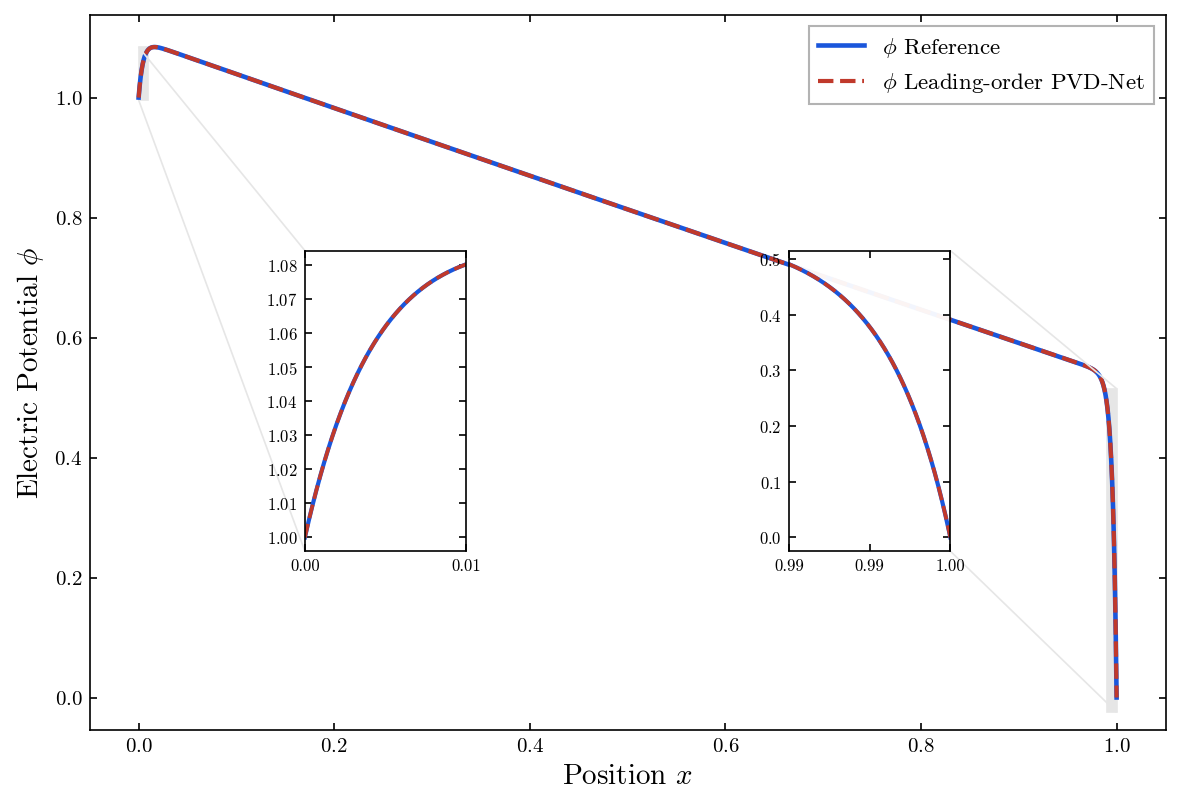

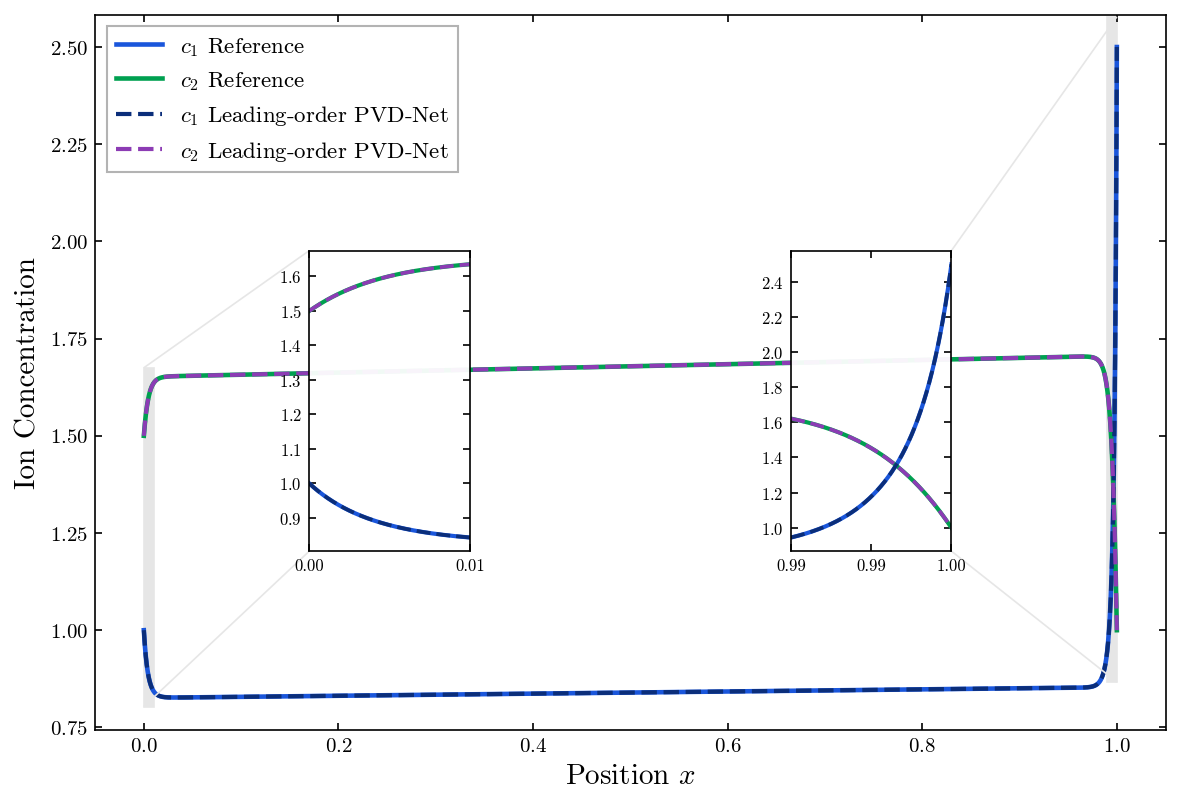

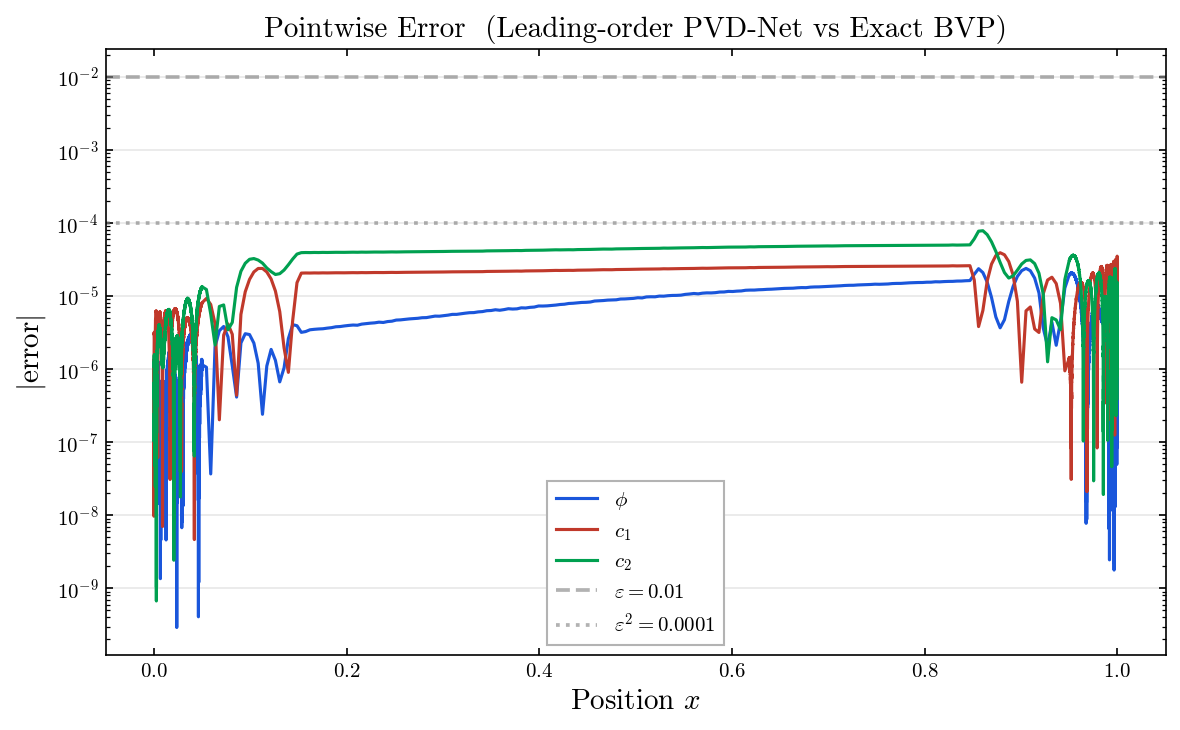

In [11]:
"""
plot_inset.py  —  带边界层放大嵌入图的可视化函数
替换原 notebook 中的 plot_vs_exact，将 c₁/c₂ 和边界层放大图合到同一张图中。
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ============================================================
# Colors matching the TikZ diagram palette
# ============================================================
BLUE    = '#1a56db'   # reference / c1 exact
RED     = '#c0392b'   # NN / c1 NN
GREEN   = '#00a050'   # c2 exact (or error φ)
PURPLE  = '#8c3cb4'   # c2 NN
ORANGE  = '#e67e22'   # error c2
BLUE_D  = '#0b2e7a'   # darker blue variant
GREEN_D = '#005c2e'   # darker green variant


def plot_with_inset(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex,
                    eps, method_name,
                    bl_left=0.01, bl_right=0.990,
                    save_path=None):
    """
    生成两张图:
      图1: 电势 φ —— 主图 + 左/右边界层放大
      图2: 浓度 c₁, c₂ —— 主图 + 左/右边界层放大
    每张图的风格与 TikZ 通道示意图一致。

    参数:
        x            : 评估网格 (1-D array)
        phi_nn, ...  : NN 解
        phi_ex, ...  : 精确解
        eps          : Debye 长度参数
        method_name  : 图例标签
        bl_left      : 左边界层放大截止 x 值
        bl_right     : 右边界层放大起始 x 值
        save_path    : 若给出，保存 PNG/PDF
    """

    figs = []
    mask_L = x <= bl_left
    mask_R = x >= bl_right

    # helper: inset tick style
    def _style_inset(ins):
        ins.tick_params(labelsize=8, direction='in')
        ins.patch.set_alpha(0.95)

    # ================================================================
    #  图1: 电势 φ
    # ================================================================
    fig1, ax1 = plt.subplots(figsize=(8, 5.5))
    ax1.plot(x, phi_ex, color=BLUE, ls='-',  lw=2.2, label=r'$\phi$ Reference')
    ax1.plot(x, phi_nn, color=RED,  ls='--', lw=2.0, label=rf'$\phi$ {method_name}')
    ax1.set_xlabel(r'Position $x$')
    ax1.set_ylabel(r'Electric Potential $\phi$')
    ax1.legend(loc='upper right')

    # ---- 左边界层放大 ----
    if np.any(mask_L):
        ax_inL = ax1.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_inL.plot(x[mask_L], phi_ex[mask_L], color=BLUE, ls='-',  lw=2)
        ax_inL.plot(x[mask_L], phi_nn[mask_L], color=RED,  ls='--', lw=1.8)
        ax_inL.set_xlim(0, bl_left)
        ax_inL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_inL.set_xticks([0, bl_left])
        _style_inset(ax_inL)
        mark_inset(ax1, ax_inL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    # ---- 右边界层放大 ----
    if np.any(mask_R):
        ax_inR = ax1.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_inR.plot(x[mask_R], phi_ex[mask_R], color=BLUE, ls='-',  lw=2)
        ax_inR.plot(x[mask_R], phi_nn[mask_R], color=RED,  ls='--', lw=1.8)
        ax_inR.set_xlim(bl_right, 1)
        ax_inR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_inR)
        mark_inset(ax1, ax_inR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig1.tight_layout()
    figs.append(fig1)

    # ================================================================
    #  图2: 浓度 c₁, c₂
    # ================================================================
    fig2, ax2 = plt.subplots(figsize=(8, 5.5))
    ax2.plot(x, c1_ex, color=BLUE,   ls='-',  lw=2.2, label=r'$c_1$ Reference')
    ax2.plot(x, c2_ex, color=GREEN,  ls='-',  lw=2.2, label=r'$c_2$ Reference')
    ax2.plot(x, c1_nn, color=BLUE_D, ls='--', lw=2.0, label=rf'$c_1$ {method_name}')
    ax2.plot(x, c2_nn, color=PURPLE, ls='--', lw=2.0, label=rf'$c_2$ {method_name}')
    ax2.set_xlabel(r'Position $x$')
    ax2.set_ylabel('Ion Concentration')
    ax2.legend(loc='best')

    # ---- 左边界层放大 ----
    if np.any(mask_L):
        ax_cL = ax2.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_cL.plot(x[mask_L], c1_ex[mask_L], color=BLUE,   ls='-',  lw=2)
        ax_cL.plot(x[mask_L], c2_ex[mask_L], color=GREEN,  ls='-',  lw=2)
        ax_cL.plot(x[mask_L], c1_nn[mask_L], color=BLUE_D, ls='--', lw=1.8)
        ax_cL.plot(x[mask_L], c2_nn[mask_L], color=PURPLE, ls='--', lw=1.8)
        ax_cL.set_xlim(0, bl_left)
        ax_cL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_cL.set_xticks([0, bl_left])
        _style_inset(ax_cL)
        mark_inset(ax2, ax_cL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    # ---- 右边界层放大 ----
    if np.any(mask_R):
        ax_cR = ax2.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_cR.plot(x[mask_R], c1_ex[mask_R], color=BLUE,   ls='-',  lw=2)
        ax_cR.plot(x[mask_R], c2_ex[mask_R], color=GREEN,  ls='-',  lw=2)
        ax_cR.plot(x[mask_R], c1_nn[mask_R], color=BLUE_D, ls='--', lw=1.8)
        ax_cR.plot(x[mask_R], c2_nn[mask_R], color=PURPLE, ls='--', lw=1.8)
        ax_cR.set_xlim(bl_right, 1)
        ax_cR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_cR)
        mark_inset(ax2, ax_cR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig2.tight_layout()
    figs.append(fig2)

    # ================================================================
    #  图3: 逐点误差 (semilogy)
    # ================================================================
    fig3, ax3 = plt.subplots(figsize=(8, 5))
    for var, u_nn, u_ex, clr in [(r'$\phi$', phi_nn, phi_ex, BLUE),
                                  (r'$c_1$', c1_nn,  c1_ex,  RED),
                                  (r'$c_2$', c2_nn,  c2_ex,  GREEN)]:
        ax3.semilogy(x, np.abs(u_nn - u_ex) + 1e-16, color=clr, ls='-',
                     lw=1.5, label=var)
    ax3.axhline(eps,    color='gray', ls='--', alpha=0.6,
                label=rf'$\varepsilon={eps}$')
    ax3.axhline(eps**2, color='gray', ls=':',  alpha=0.6,
                label=rf'$\varepsilon^2={eps**2}$')
    ax3.set_xlabel(r'Position $x$')
    ax3.set_ylabel(r'$|$error$|$')
    ax3.set_title(rf'Pointwise Error  ({method_name} vs Exact BVP)',
                  fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    fig3.tight_layout()
    figs.append(fig3)

    # ---- 保存 ----
    if save_path:
        names = ['phi', 'concentration', 'error']
        for i, fig in enumerate(figs):
            fig.savefig(f'{save_path}_{names[i]}.pdf', bbox_inches='tight')
            fig.savefig(f'{save_path}_{names[i]}.png', bbox_inches='tight')

    plt.show()
    return figs

figs = plot_with_inset(x_eval, phi_nn, c1_nn, c2_nn,
                         phi_ex, c1_ex, c2_ex, eps, 'High-order PVD-Net')

## 12. 五次独立实验 (固定随机种子)


# ============================================================
#  五次独立实验 (固定随机种子, 报告 mean ± std)
# ============================================================
import copy, time

SEEDS = [0, 1, 2, 3, 4]          # 固定随机种子, 保证可复现
N_RUNS = len(SEEDS)

print('求解精确参考解 ...')
sol_exact = compute_exact_reference(eps, V, L1, L2, R1, R2)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
y_ex = sol_exact.sol(x_eval)
phi_ex, c1_ex, c2_ex = y_ex[0], y_ex[2], y_ex[3]
J1_ex, J2_ex = y_ex[4, 0], y_ex[5, 0]
print(f'精确解通量: J1={J1_ex:.6f}, J2={J2_ex:.6f}, I=2J1-J2={2*J1_ex-J2_ex:.6f}')

all_metrics, all_times = [], []

for run in range(N_RUNS):
    torch.manual_seed(SEEDS[run])
    np.random.seed(SEEDS[run])
    print(f'\n{"="*50}')
    print(f'  Run {run+1}/{N_RUNS}   (seed = {SEEDS[run]})')
    print(f'{"="*50}')
    t0 = time.time()

    model_i = create_pvdnet(eps, hidden=33, layers=5, device=DEVICE)
    history_i = train(model_i, V, L1, L2, R1, R2,
                      epochs=300000, log_interval=30000)
    elapsed = time.time() - t0
    all_times.append(elapsed)

    x_t = torch.tensor(x_eval.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        phi_t, c1_t, c2_t = forward_pvdnet(model_i, x_t)
    phi_nn = phi_t.cpu().numpy().flatten()
    c1_nn = c1_t.cpu().numpy().flatten()
    c2_nn = c2_t.cpu().numpy().flatten()
    J10_nn, J20_nn, J11_nn, J21_nn = get_flux(model_i)
    J1_nn = J10_nn + eps*J11_nn
    J2_nn = J20_nn + eps*J21_nn

    m = compute_unified_metrics(
        phi_nn, c1_nn, c2_nn, J1_nn, J2_nn,
        phi_ex, c1_ex, c2_ex, J1_ex, J2_ex, grids)
    all_metrics.append(m)
    print(f'  用时 {elapsed:.1f}s  |  全局相对L²(φ)={m["phi"]["global_rel_L2"]:.4e}')

print(f'\n全部 {N_RUNS} 次实验完成!')

metric_keys = ['global_rel_L2', 'global_Linf', 'inner_rel_L2',
               'inner_Linf', 'junction_err']
metric_labels = ['① 全局相对 L²', '② 全局 L∞', '③ 内区域相对 L²',
                 '④ 内区域 L∞', '⑤ 交界点误差']
var_names = ['phi', 'c1', 'c2']

print(f'\n{"="*80}')
print(f'  一阶 PVD-Net (2:-1)  {N_RUNS} 次随机实验统计  (Setting B, 2:-1, ε = {eps})')
print(f'{"="*80}')
print(f'{"指标":<22s} | {"phi (mean±std)":>24s} | {"c1 (mean±std)":>24s} | {"c2 (mean±std)":>24s}')
print(f'{"-"*22}-+-{"-"*24}-+-{"-"*24}-+-{"-"*24}')
for mk, ml in zip(metric_keys, metric_labels):
    row = []
    for v in var_names:
        vals = np.array([m[v][mk] for m in all_metrics])
        row.append(f'{vals.mean():.4e} ± {vals.std():.4e}')
    print(f'{ml:<22s} | {row[0]:>24s} | {row[1]:>24s} | {row[2]:>24s}')
print(f'{"-"*22}-+-{"-"*24}-+-{"-"*24}-+-{"-"*24}')
print(f'  训练用时: {np.mean(all_times):.1f} ± {np.std(all_times):.1f} s')